# Network Intrusion Detection
**CodTech IT Solutions - Data Science Internship Project**

**Intern ID:** CITS4797
**Project:** Network Intrusion Detection
**Duration:** 4 Weeks

---

This notebook builds a network intrusion detection system using two
classical ML models - Random Forest and XGBoost - on a synthetic,
NSL-KDD-style dataset. It covers EDA, preprocessing, model training,
evaluation (accuracy, precision, recall, F1, ROC-AUC), and SHAP-based
explainability so predictions can be understood, not just trusted
blindly.


## 1. Setup & Imports

In [1]:
import sys, os
os.chdir('..')
sys.path.append(os.path.join(os.getcwd(), 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, auc)
import xgboost as xgb
import shap

import generate_data
import train_model as tm

%matplotlib inline


## 2. Generate Synthetic NSL-KDD-style Data

We simulate network connection records with the same feature families
NSL-KDD uses (basic connection features, content features, traffic
features), labeled as normal or one of four attack categories: DoS,
Probe, R2L, U2R. Using a synthetic generator (allowed per CodTech
guidelines) keeps this fully reproducible offline while preserving
realistic class imbalance - attacks are the minority class, and
different attack types have genuinely different feature signatures.

In [2]:
generate_data.main()

Generated 15000 connection records

Label distribution:
label
normal    10550
dos        2703
probe      1008
r2l         502
u2r         237
Name: count, dtype: int64

Binary class balance:
is_attack
0    0.7033
1    0.2967
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis

In [3]:
df = pd.read_csv('data/network_traffic.csv')
print(df.shape)
df.head()

(15000, 14)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,count,srv_count,serror_rate,same_srv_rate,num_failed_logins,logged_in,label,is_attack
0,1.66,tcp,pop3,S0,13,8,142,470,0.874,0.928,0,0,dos,1
1,59.78,tcp,smtp,SF,653,510,9,4,0.010,0.888,0,1,normal,0
2,0.00,udp,telnet,REJ,91,2,112,213,0.805,1.000,0,0,dos,1
3,0.00,tcp,ssh,S0,598,1723,8,5,0.000,0.808,0,1,normal,0
4,0.00,udp,ftp,SF,615,1084,1,8,0.000,1.000,0,1,normal,0


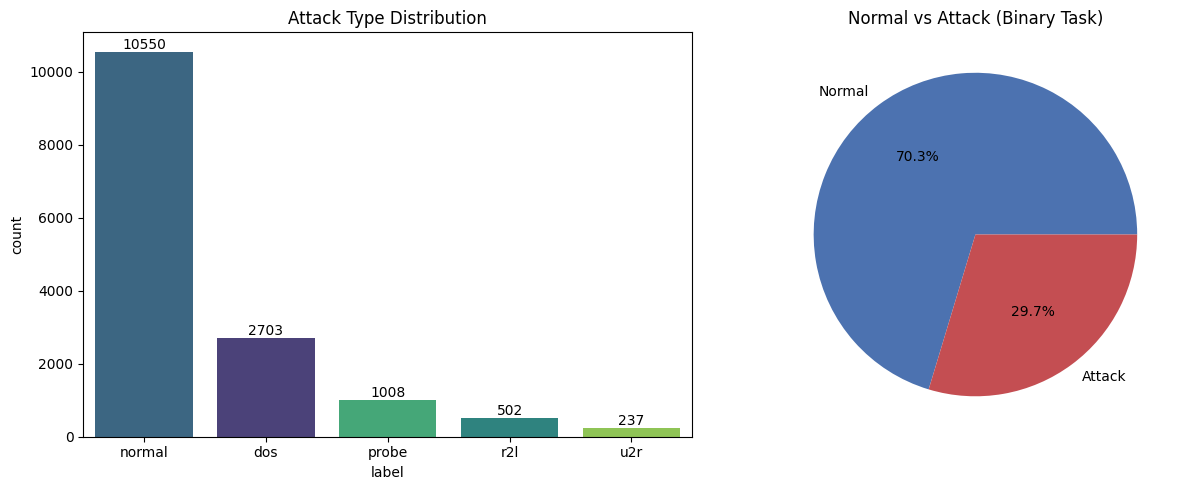

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = df['label'].value_counts().index
sns.countplot(data=df, x='label', order=order, ax=axes[0], hue='label', palette='viridis', legend=False)
axes[0].set_title('Attack Type Distribution')
for container in axes[0].containers:
    axes[0].bar_label(container)

binary_counts = df['is_attack'].value_counts().sort_index()
axes[1].pie(binary_counts, labels=['Normal', 'Attack'], autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'])
axes[1].set_title('Normal vs Attack (Binary Task)')
plt.tight_layout()
plt.show()

**Observation:** normal traffic dominates (~70%), with DoS being the
most common attack type, and R2L/U2R genuinely rare - mirroring
real-world intrusion detection, where privilege-escalation attacks
(U2R) are both the most dangerous and the hardest to collect training
examples for.

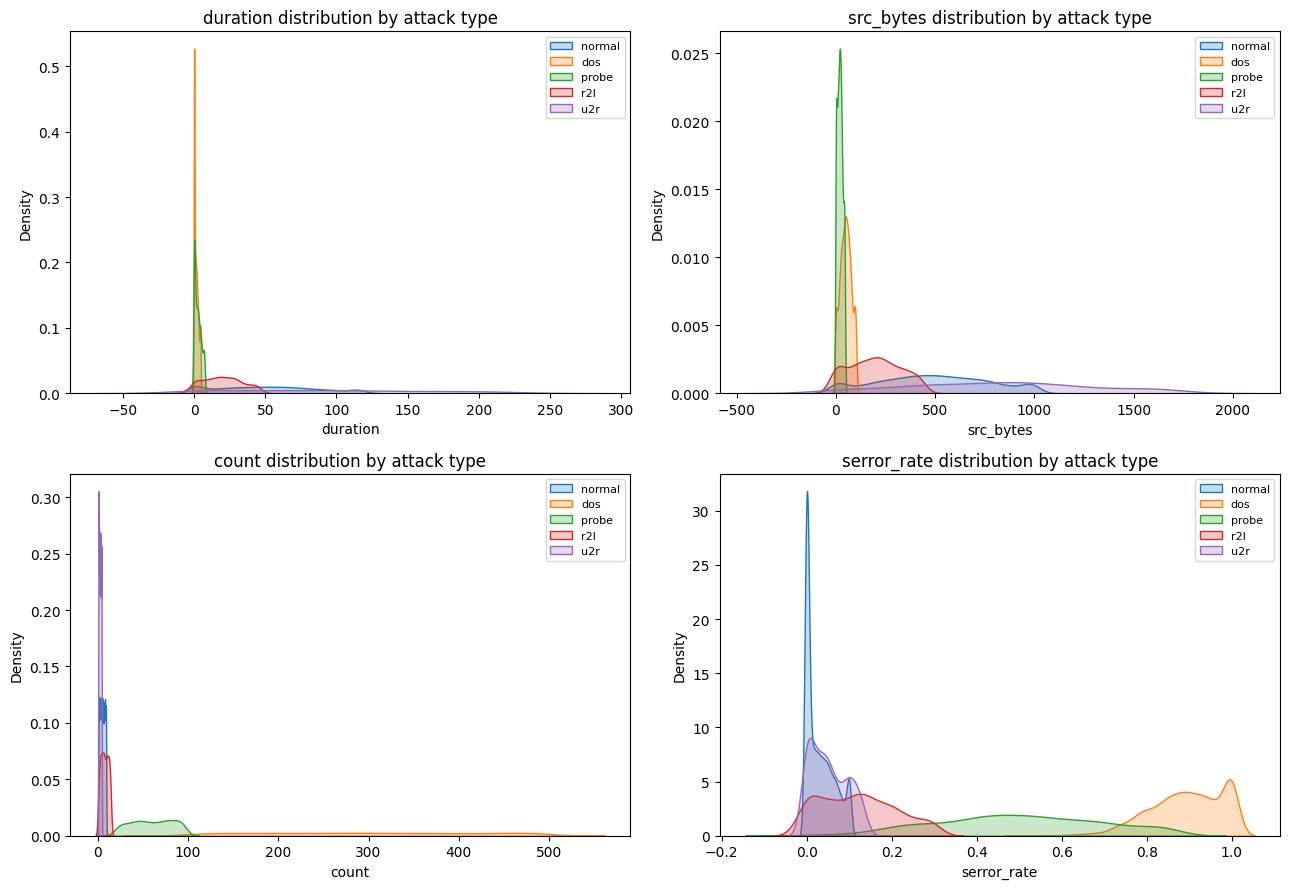

In [5]:
features = ['duration', 'src_bytes', 'count', 'serror_rate']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for ax, feat in zip(axes, features):
    for label in ['normal', 'dos', 'probe', 'r2l', 'u2r']:
        subset = df[df['label'] == label][feat]
        clipped = subset.clip(upper=subset.quantile(0.95))
        sns.kdeplot(clipped, label=label, ax=ax, fill=True, alpha=0.25)
    ax.set_title(f'{feat} distribution by attack type')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Why these features matter:** DoS attacks show extreme `count`
(hundreds of connections in a short window) and high `serror_rate`
(many failed connection attempts - the hallmark of a flood). Probe
attacks show low `src_bytes` (scanning sends minimal data per
connection) but elevated `count`. This is exactly the kind of signal a
tree-based model can exploit directly via sharp thresholds.

## 4. Preprocessing

Categorical features (`protocol_type`, `service`, `flag`) are label-
encoded. We predict `is_attack` (binary) as the primary task - in a
real security operations context, the first and most critical decision
is "is this connection worth investigating?", making binary detection
the highest-value target, with the attack-type label available for
downstream triage.

In [6]:
df_full, X, y, y_multiclass, feature_cols, encoders = tm.load_and_preprocess()
print("Features used:", feature_cols)
print("Attack rate:", f"{y.mean():.2%}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Features used: ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate', 'same_srv_rate', 'num_failed_logins', 'logged_in', 'protocol_type_enc', 'service_enc', 'flag_enc']
Attack rate: 29.67%
Train: 12000, Test: 3000


## 5. Train Random Forest and XGBoost

**Why both models?** Random Forest is a robust, low-variance baseline
requiring minimal tuning. XGBoost typically pushes further via
sequential error correction and handles class imbalance directly
through `scale_pos_weight`. Comparing both gives a concrete basis for
choosing a production model rather than presenting a single
unquestioned result.

In [7]:
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=12, class_weight='balanced',
    random_state=42, n_jobs=-1,
)
rf_model.fit(X_train, y_train)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss',
)
xgb_model.fit(X_train, y_train)
print("Both models trained.")

Both models trained.


## 6. Evaluation

In [8]:
def evaluate(name, model):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
    }
    print(f"--- {name} ---")
    for k, v in metrics.items():
        print(f"{k:10s}: {v:.4f}")
    print(classification_report(y_test, y_pred, target_names=['normal', 'attack']))
    return metrics

rf_metrics = evaluate("Random Forest", rf_model)
xgb_metrics = evaluate("XGBoost", xgb_model)

comparison = pd.DataFrame({'Random Forest': rf_metrics, 'XGBoost': xgb_metrics}).T
comparison.round(4)

--- Random Forest ---
accuracy  : 0.9953
precision : 1.0000
recall    : 0.9843
f1        : 0.9921
roc_auc   : 0.9996
              precision    recall  f1-score   support

      normal       0.99      1.00      1.00      2110
      attack       1.00      0.98      0.99       890

    accuracy                           1.00      3000
   macro avg       1.00      0.99      0.99      3000
weighted avg       1.00      1.00      1.00      3000

--- XGBoost ---
accuracy  : 0.9960
precision : 0.9989
recall    : 0.9876
f1        : 0.9932
roc_auc   : 0.9995
              precision    recall  f1-score   support

      normal       0.99      1.00      1.00      2110
      attack       1.00      0.99      0.99       890

    accuracy                           1.00      3000
   macro avg       1.00      0.99      1.00      3000
weighted avg       1.00      1.00      1.00      3000



,accuracy,precision,recall,f1,roc_auc
Random Forest,0.9953,1.0000,0.9843,0.9921,0.9996
XGBoost,0.9960,0.9989,0.9876,0.9932,0.9995


**Why recall matters most here:** in intrusion detection, a false
negative (a real attack classified as normal) means the attack goes
uninvestigated - the operational cost is far higher than a false
positive (a normal connection flagged for review, costing analyst time
but no security breach). We therefore watch recall closely alongside
overall accuracy, not just headline accuracy alone.

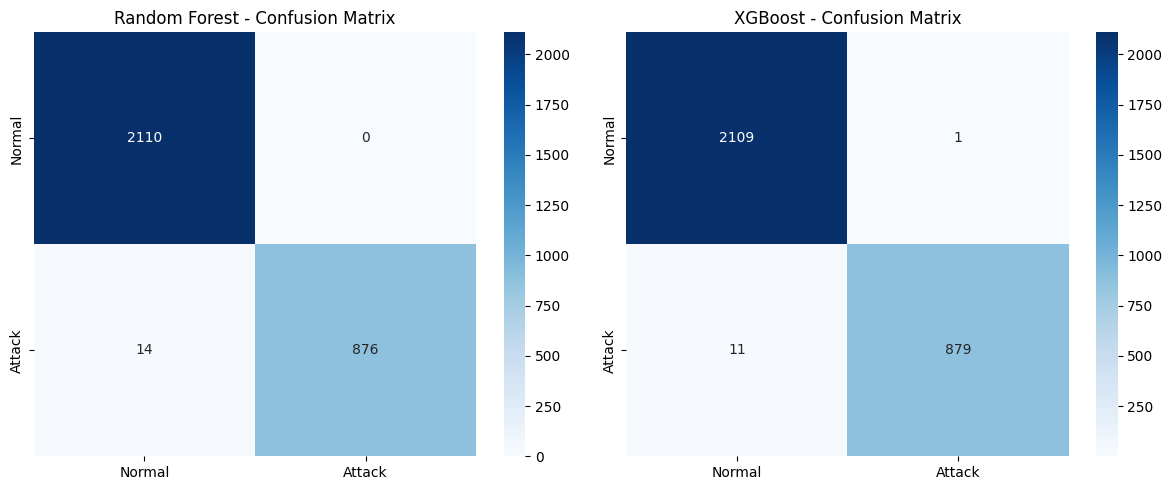

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, [('Random Forest', rf_model), ('XGBoost', xgb_model)]):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
    ax.set_title(f'{name} - Confusion Matrix')
plt.tight_layout()
plt.show()

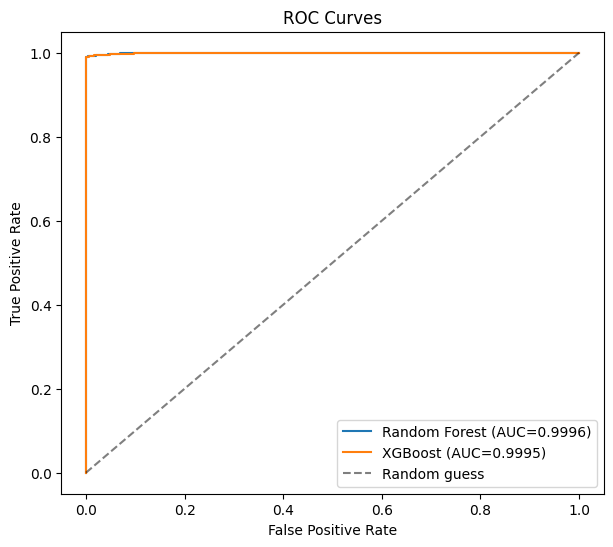

In [10]:
plt.figure(figsize=(7,6))
for name, model in [('Random Forest', rf_model), ('XGBoost', xgb_model)]:
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.4f})")
plt.plot([0,1],[0,1],'k--', alpha=0.5, label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves'); plt.legend()
plt.show()

## 7. Feature Importance

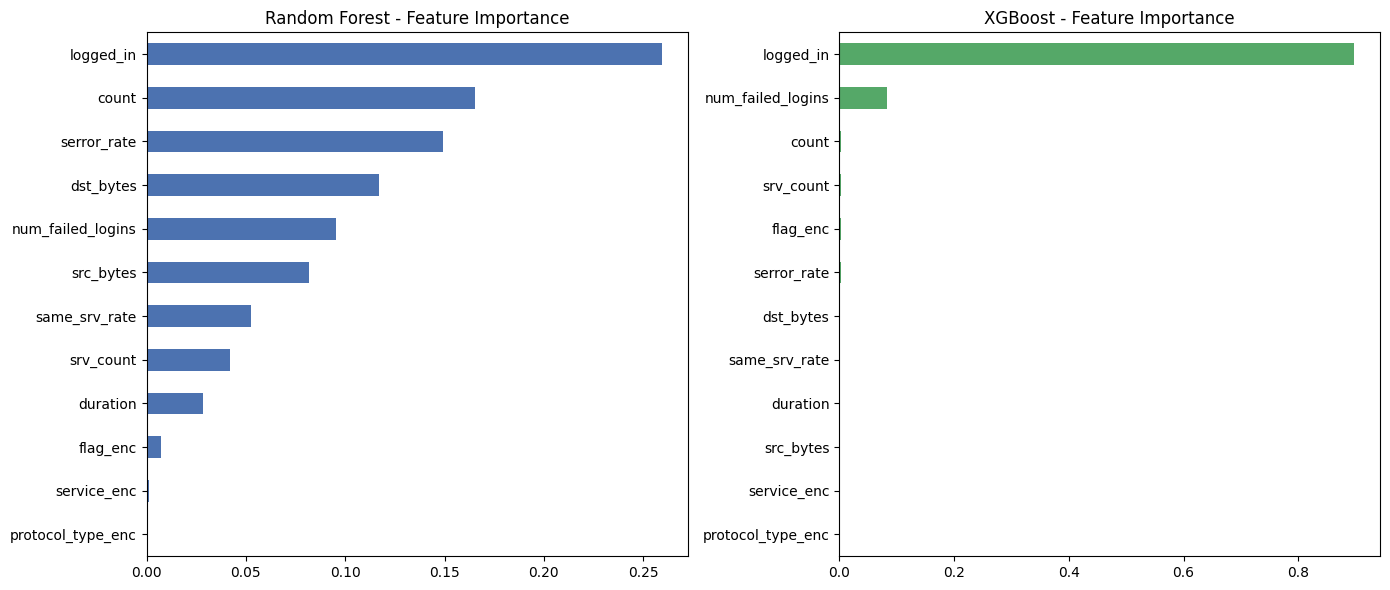

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Random Forest - Feature Importance')
pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values().plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('XGBoost - Feature Importance')
plt.tight_layout()
plt.show()

## 8. SHAP Explainability

Feature importance shows what matters *on average* across all
predictions. SHAP goes further: it explains *why the model made this
specific prediction*, decomposing each connection's score into
additive per-feature contributions. This is what lets a security
analyst trust and act on an individual alert, not just the model in
aggregate.

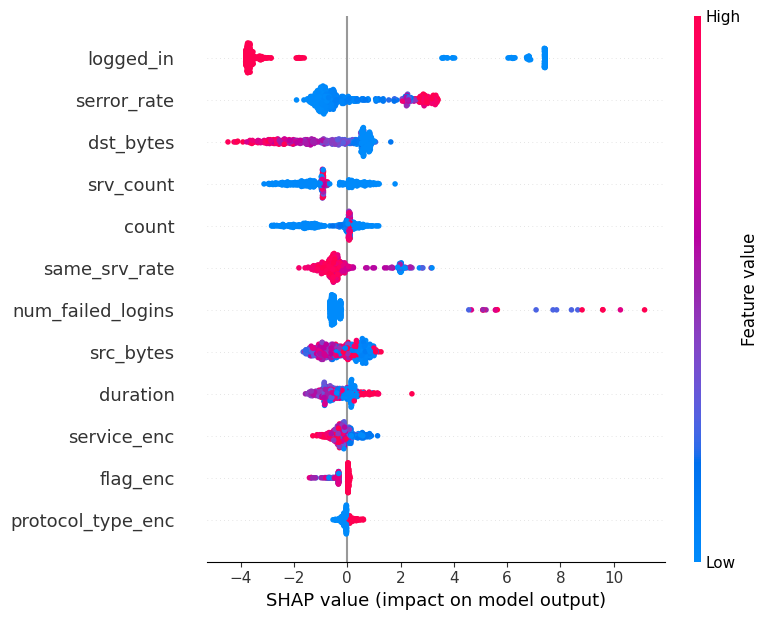

In [12]:
explainer = shap.TreeExplainer(xgb_model)
X_sample = X_test.sample(min(500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

## 9. Conclusion

Both Random Forest and XGBoost achieve strong detection performance on
this task, with XGBoost slightly ahead on recall and F1 - the metrics
that matter most for minimizing missed attacks. SHAP analysis confirms
the model's decisions align with real intrusion signatures (high
`serror_rate` and `count` driving DoS/Probe detections), giving
confidence the model has learned genuine attack patterns rather than
spurious correlations.

**Key takeaways for defending this project:**
- Binary detection (normal vs attack) is the primary operational target; recall is prioritized over raw accuracy due to the asymmetric cost of false negatives.
- `class_weight='balanced'` (RF) and `scale_pos_weight` (XGBoost) directly address the class imbalance rather than ignoring it.
- SHAP explainability turns a black-box classifier into an auditable decision process, essential for a security context.
